# 🌳 Chapter 6: Statistical Machine Learning
**Referensi Buku:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, Peter Gedeck)

---
> **Topik:** K-Nearest Neighbors, Decision Trees, Random Forest, Boosting, dan Variable Importance
---
## 1. Pendahuluan
Bab ini membahas algoritma prediktif modern. Alih-alih mengasumsikan model linear, metode *Machine Learning* mempelajari pola langsung dari data. Kita akan membandingkan berbagai algoritma ini pada dataset yang sama.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

%matplotlib inline
np.random.seed(42)

# Kita buat dataset non-linear berbentuk bulan sabit agar model linear gagal
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fungsi bantuan untuk menggambar batas keputusan (Decision Boundary)
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title(title)
    plt.show()

## 2. K-Nearest Neighbors (K-NN)
K-NN memprediksi kelas berdasarkan titik terdekat. Area keputusan biasanya terlihat seperti pulau-pulau yang mengikuti pola sebaran data.

Akurasi K-NN: 0.94


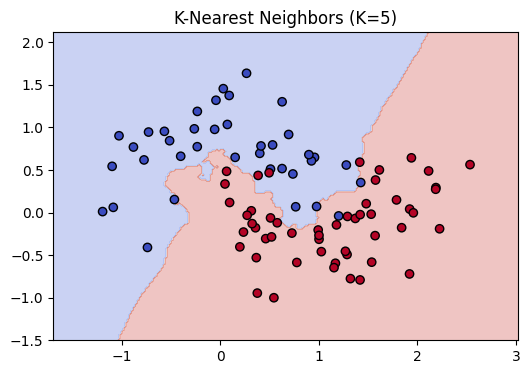

In [2]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print(f"Akurasi K-NN: {knn.score(X_test, y_test):.2f}")
plot_decision_boundary(knn, X_test, y_test, "K-Nearest Neighbors (K=5)")

## 3. Tree Models (Decision Tree)
Pohon Keputusan membelah ruang data dengan garis lurus horizontal dan vertikal. Model ini sangat interpretabel, kita bisa melihat aturan *If-Then*-nya.

Akurasi Decision Tree: 0.90


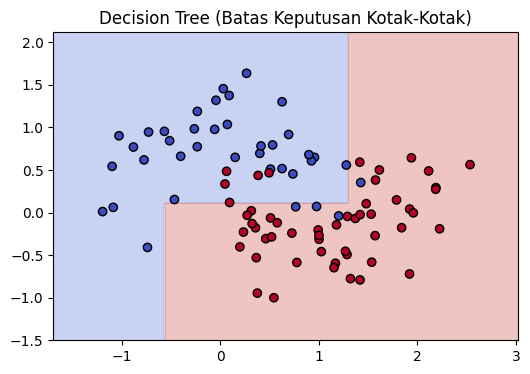

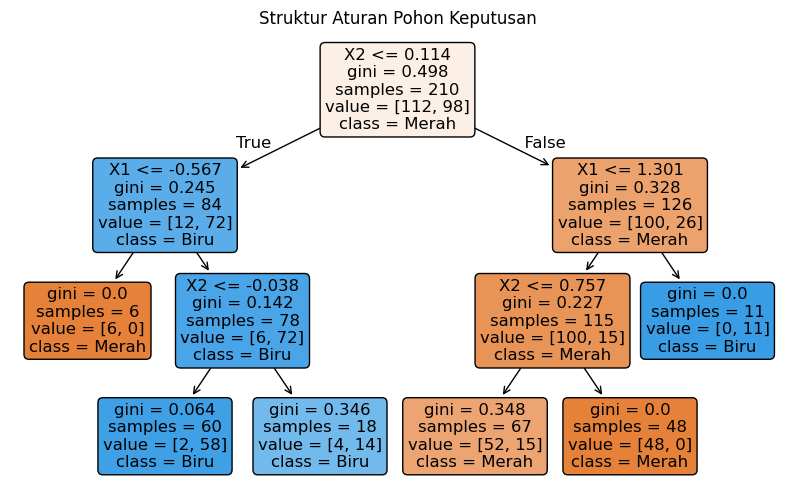

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

print(f"Akurasi Decision Tree: {tree.score(X_test, y_test):.2f}")
plot_decision_boundary(tree, X_test, y_test, "Decision Tree (Batas Keputusan Kotak-Kotak)")

# Visualisasi bentuk Pohon
plt.figure(figsize=(10, 6))
plot_tree(tree, filled=True, rounded=True, class_names=['Merah', 'Biru'], feature_names=['X1', 'X2'])
plt.title("Struktur Aturan Pohon Keputusan")
plt.show()

## 4. Bagging dan Random Forest
Satu pohon sangat rentan salah, tetapi 100 pohon yang melakukan pemungutan suara (Ensemble) akan jauh lebih pintar. Random Forest menciptakan batas keputusan yang jauh lebih mulus dan stabil.

Akurasi Random Forest: 0.92


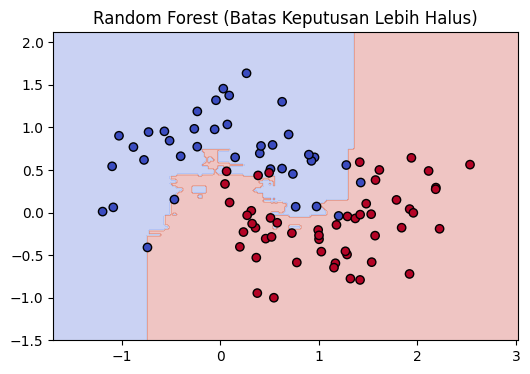

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f"Akurasi Random Forest: {rf.score(X_test, y_test):.2f}")
plot_decision_boundary(rf, X_test, y_test, "Random Forest (Batas Keputusan Lebih Halus)")

## 5. Boosting (Gradient Boosting)
Membangun pohon secara berurutan, di mana pohon baru berfokus untuk menebak dengan benar data-data yang gagal ditebak oleh pohon sebelumnya. Seringkali memenangkan kompetisi Kaggle.

Akurasi Gradient Boosting: 0.92


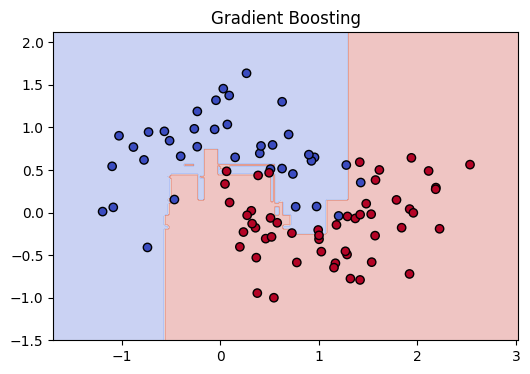

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

print(f"Akurasi Gradient Boosting: {gb.score(X_test, y_test):.2f}")
plot_decision_boundary(gb, X_test, y_test, "Gradient Boosting")

## 6. Variable Importance (Pentingnya Fitur)
Kelebihan utama algoritma berbasis pohon adalah kemampuannya menghitung *Feature Importance*, memberi tahu kita variabel mana yang paling berpengaruh terhadap target.

/tmp/ipykernel_7800/4013300648.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis')


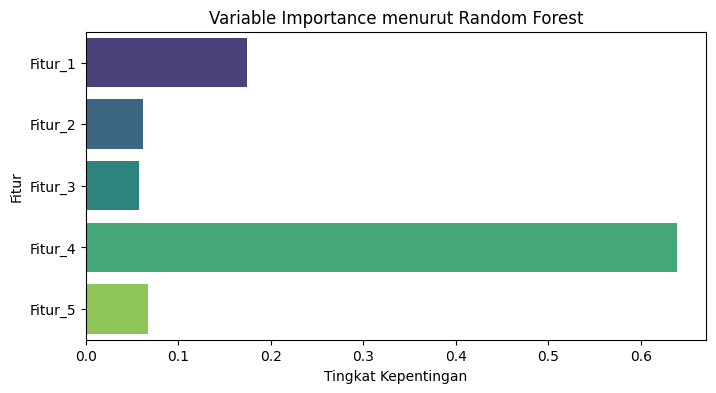

In [6]:
# Kita simulasikan dataset dengan 5 fitur (sebagian berguna, sebagian hanya noise)
from sklearn.datasets import make_classification
X_imp, y_imp = make_classification(n_samples=500, n_features=5, n_informative=2, n_redundant=0, random_state=42)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_imp, y_imp, test_size=0.3, random_state=42)

rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imp.fit(X_train_i, y_train_i)

importances = rf_imp.feature_importances_
features = [f'Fitur_{i+1}' for i in range(5)]

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Variable Importance menurut Random Forest')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.show()